<a href="https://colab.research.google.com/github/harshinisathya09-star/projects-/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Housing.csv")

In [ ]:
print(df.mean(numeric_only=True))

price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935780e-01
dtype: float64


In [ ]:
print(df.median(numeric_only=True))

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64


In [ ]:
print(df.mode)

<bound method DataFrame.mode of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no

In [ ]:
print(df.std(numeric_only=True))

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64


In [ ]:
print(df.std(numeric_only=True))

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64


In [ ]:
print(df.skew(numeric_only=True))

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64


In [ ]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", len(outliers), "outliers")

price : 15 outliers
area : 12 outliers
bedrooms : 12 outliers
bathrooms : 1 outliers
stories : 41 outliers
parking : 12 outliers


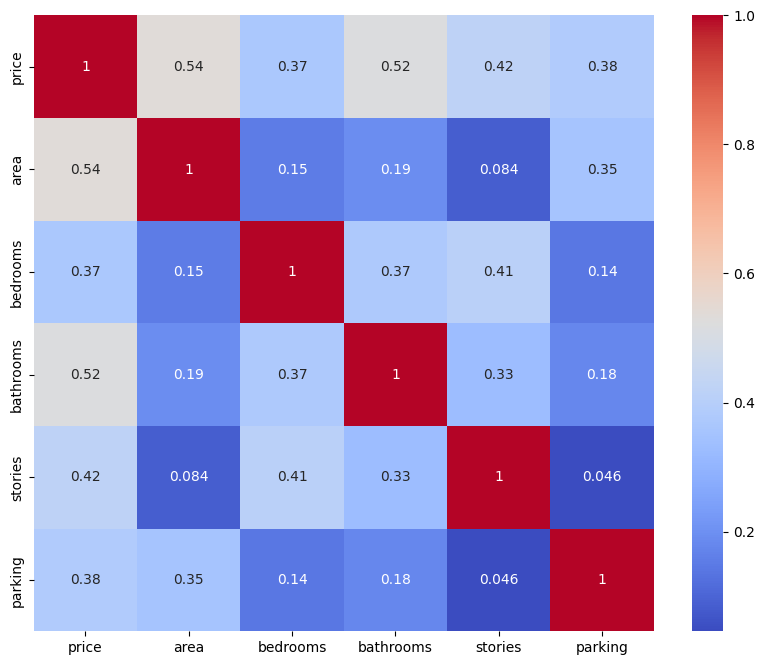

In [ ]:
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
print(corr["price"].sort_values(ascending=False))

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
categorical = df.select_dtypes(include='object').columns
for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
from sklearn.model_selection import train_test_split
X = df[['area']]
y = df['price']
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
simple_model = LinearRegression()
simple_model.fit(X_train,y_train)
simple_pred = simple_model.predict(X_test)

In [ ]:
X = df.drop("price",axis=1)
y = df["price"]
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 1331071.4167895108
R2 Score: 0.6494754192267803


In [ ]:
new_houses = X_test.head(10)
predictions = model.predict(new_houses)
print(predictions)

[5203691.70963178 7257004.02115475 3062828.59668171 4559591.65374424
 3332932.30559782 3563080.67918997 5645466.31219972 6413979.66873635
 2755831.54819    2668938.66075228]


In [ ]:
result = pd.DataFrame({
    "Actual Price": y_test.head(10).values,
    "Predicted Price": predictions
})
print(result)

   Actual Price  Predicted Price
0       4060000     5.203692e+06
1       6650000     7.257004e+06
2       3710000     3.062829e+06
3       6440000     4.559592e+06
4       2800000     3.332932e+06
5       4900000     3.563081e+06
6       5250000     5.645466e+06
7       4543000     6.413980e+06
8       2450000     2.755832e+06
9       3353000     2.668939e+06


In [ ]:
import joblib
joblib.dump(model,"house_price_model.pkl")
print("Model saved successfully.")

Model saved successfully.
